# Stage 3: Structural Analysis (Extraction)

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 2.0.0 | 2026-01-26 | That Le | Complete Stage 3 documentation |

---

## Overview

Stage 3 is the **most complex stage** - it extracts all structural information from chart images.

### Input/Output

| Property | Value |
| --- | --- |
| **Input** | `Stage2Output` (List of `DetectedChart`) |
| **Output** | `Stage3Output` (List of `RawMetadata`) |
| **Key Components** | Classifier, OCR, Element Detector, Geometric Mapper |

### Processing Flow (Parallel)

```
Stage2Output (Cropped Charts)
       |
       v
+--------------------------------------------------+
|              PARALLEL PROCESSING                 |
|  +------------+  +------------+  +------------+  |
|  | CLASSIFIER |  |    OCR     |  |  ELEMENT   |  |
|  | ResNet-18  |  | PaddleOCR  |  | DETECTOR   |  |
|  | 94.66% acc |  | Multi-lang |  | K-Means +  |  |
|  +------------+  +------------+  | Contours   |  |
|        |              |          +------------+  |
|        v              v                |         |
|   ChartType       OCRText[]        Elements[]    |
+--------------------------------------------------+
       |
       v
+----------------------+
| GEOMETRIC ANALYSIS   |
| - Axis detection     |
| - Scale calibration  |
| - Coordinate mapping |
+----------------------+
       |
       v
RawMetadata (combined)
```

---

## Output Schema

```python
class RawMetadata(BaseModel):
    """Raw extracted data from Stage 3."""
    chart_id: str                        # From Stage 2
    chart_type: ChartType                # bar, line, pie, scatter...
    texts: List[OCRText]                 # All extracted text
    elements: List[ChartElement]         # Bars, points, slices
    axis_info: Optional[AxisInfo]        # Axis calibration data

class OCRText(BaseModel):
    """Extracted text element."""
    text: str                            # Text content
    bbox: BoundingBox                    # Location
    confidence: float                    # OCR confidence [0-1]
    role: Optional[str]                  # title/xlabel/ylabel/legend/value

class ChartElement(BaseModel):
    """Detected chart element."""
    element_type: str                    # bar, point, slice, line
    bbox: BoundingBox                    # Bounding box
    center: Point                        # Center point
    color: Optional[Color]               # Dominant color
    area_pixels: Optional[int]           # Area in pixels
```

---

## Configuration

In [1]:
# ============================================================================
# EXECUTION CONTROL FLAGS
# ============================================================================
# Adjust these settings to control notebook behavior
# ============================================================================

EXECUTE_EXAMPLES = True   # Run actual code examples (loads heavy models)
SHOW_IMAGES = True        # Display visualization images
NUM_TEST_IMAGES = 20       # Number of images to test per section (1-10)

# ============================================================================
print(f"Execution mode: {'ACTIVE' if EXECUTE_EXAMPLES else 'DOCUMENTATION ONLY'}")
print(f"Show images: {SHOW_IMAGES}")
print(f"Test images per section: {NUM_TEST_IMAGES}")

Execution mode: ACTIVE
Show images: True
Test images per section: 20


In [2]:
# ============================================================================
# ENVIRONMENT SETUP (Always runs)
# ============================================================================
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

# Check for model files
model_files = [
    ("ResNet-18 Classifier", PROJECT_ROOT / "models" / "weights" / "resnet18_chart_classifier.onnx"),
    ("ResNet-18 PyTorch", PROJECT_ROOT / "models" / "weights" / "resnet18_chart_classifier.pth"),
]
print("\nModel files:")
for name, path in model_files:
    status = "FOUND" if path.exists() else "NOT FOUND"
    size = f"({path.stat().st_size / 1024 / 1024:.1f} MB)" if path.exists() else ""
    print(f"  [{status}] {name} {size}")

Project root: d:\elix\chart_analysis_ai_v3

Model files:
  [NOT FOUND] ResNet-18 Classifier 
  [NOT FOUND] ResNet-18 PyTorch 


---

## 1. Chart Classification (ResNet-18)

**Model**: ResNet-18 trained on 8 chart types

### Performance Metrics

| Metric | Value |
| --- | --- |
| Training Accuracy | 94.66% |
| Integration Test | 93.75% (15/16 samples) |
| Inference Speed (ONNX) | 6.90ms mean (CPU) |
| Model Size | 42.64 MB |

### Supported Chart Types

| Index | Type | Description |
| --- | --- | --- |
| 0 | area | Area charts |
| 1 | bar | Vertical/horizontal bars |
| 2 | box | Box plots |
| 3 | heatmap | Heatmaps |
| 4 | histogram | Histograms |
| 5 | line | Line charts |
| 6 | pie | Pie/donut charts |
| 7 | scatter | Scatter plots |

In [3]:
# ============================================================================
# DEMO: Chart Classification with ResNet-18
# ============================================================================
if EXECUTE_EXAMPLES:
    import cv2
    import matplotlib.pyplot as plt
    from PIL import Image
    
    from src.core_engine.stages.s3_extraction.resnet_classifier import (
        ResNet18Classifier
    )
    
    # Initialize classifier - check available model files
    model_path = PROJECT_ROOT / "models" / "weights" / "resnet18_chart_classifier_best.pt"
    onnx_path = PROJECT_ROOT / "models" / "onnx" / "resnet18_chart_classifier.onnx"
    
    if model_path.exists():
        classifier = ResNet18Classifier(model_path=model_path, device='auto')
        print(f"Classifier loaded: {classifier.class_names}")
        print(f"Device: {classifier.device}")
    else:
        print(f"[ERROR] Model not found: {model_path}")
        print("Run: python scripts/train_resnet18_classifier.py")
        classifier = None
    
    # Find test images
    if classifier:
        sample_dir = PROJECT_ROOT / "data" / "academic_dataset" / "classified_charts"
        if sample_dir.exists():
            # Get NUM_TEST_IMAGES from each class
            sample_images = []
            for chart_type_dir in sample_dir.iterdir():
                if chart_type_dir.is_dir():
                    imgs = list(chart_type_dir.glob("*.png"))[:NUM_TEST_IMAGES]
                    sample_images.extend(imgs)
            
            if sample_images:
                print(f"\nClassification Results ({len(sample_images)} images):")
                print("=" * 70)
                
                correct = 0
                for img_path in sample_images:
                    chart_type, confidence = classifier.predict_with_confidence(img_path)
                    actual_type = img_path.parent.name
                    match = "OK" if chart_type == actual_type else "MISMATCH"
                    if chart_type == actual_type:
                        correct += 1
                    print(f"  {img_path.name[:35]:35} | Pred: {chart_type:10} | Conf: {confidence:.2%} | {match}")
                
                print("=" * 70)
                print(f"Accuracy: {correct}/{len(sample_images)} ({correct/len(sample_images)*100:.1f}%)")
            else:
                print("[INFO] No sample images found in classified_charts/")
                print("Run Data Factory notebooks first (01a -> 01d)")
        else:
            print(f"[INFO] Sample dir not found: {sample_dir}")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to run classification")
    print("\nExpected output:")
    print("  Classifier loaded: ['area', 'bar', 'box', 'heatmap', 'histogram', 'line', 'pie', 'scatter']")
    print("  Device: cuda / cpu")
    print("  chart_001.png | Pred: line | Conf: 95.23% | OK")

d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Classifier loaded: ['area', 'bar', 'box', 'heatmap', 'histogram', 'line', 'pie', 'scatter']
Device: cuda

Classification Results (180 images):
  arxiv_1204_3210v2_page_1_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1204_3210v2_page_2_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1204_3210v2_page_3_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1204_3210v2_page_4_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1204_3210v2_page_5_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1204_3210v2_page_6_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1204_3210v2_page_7_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1204_3210v2_page_8_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1204_3210v2_page_9_img_1.png  | Pred: area       | Conf: 73.36% | OK
  arxiv_1503_01073v1_page_50_img_5.pn | Pred: area       | Conf: 96.97% | OK
  arxiv_1503_01073v1_page_50_img_9.pn | Pred: area       | Conf: 97.84% | OK
  arxiv_18

Low confidence prediction | image=arxiv_0009177v1_page_3_img_1.png | pred=heatmap | conf=0.499 < threshold=0.5
Low confidence prediction | image=arxiv_0710_2523v2_page_24_img_1.png | pred=bar | conf=0.467 < threshold=0.5
Low confidence prediction | image=arxiv_0710_2523v2_page_24_img_2.png | pred=heatmap | conf=0.466 < threshold=0.5
Low confidence prediction | image=arxiv_0710_2523v2_page_25_img_1.png | pred=bar | conf=0.496 < threshold=0.5


  arxiv_0009177v1_page_3_img_1.png    | Pred: unknown    | Conf: 49.91% | MISMATCH
  arxiv_0011152v2_page_107_img_1.png  | Pred: line       | Conf: 67.30% | MISMATCH
  arxiv_0303483v2_page_7_img_1.png    | Pred: line       | Conf: 62.28% | MISMATCH
  arxiv_0303483v2_page_7_img_2.png    | Pred: line       | Conf: 53.76% | MISMATCH
  arxiv_0309012v1_page_5_img_1.png    | Pred: scatter    | Conf: 67.95% | MISMATCH
  arxiv_0309550v1_page_8_img_1.png    | Pred: heatmap    | Conf: 51.79% | MISMATCH
  arxiv_0311083v3_page_4_img_1.png    | Pred: scatter    | Conf: 54.23% | MISMATCH
  arxiv_0710_2523v2_page_18_img_2.png | Pred: heatmap    | Conf: 61.38% | MISMATCH
  arxiv_0710_2523v2_page_24_img_1.png | Pred: unknown    | Conf: 46.71% | MISMATCH
  arxiv_0710_2523v2_page_24_img_2.png | Pred: unknown    | Conf: 46.57% | MISMATCH
  arxiv_0710_2523v2_page_24_img_3.png | Pred: heatmap    | Conf: 55.30% | MISMATCH


Low confidence prediction | image=arxiv_0807_2646v2_page_3_img_2.png | pred=scatter | conf=0.491 < threshold=0.5
Low confidence prediction | image=arxiv_0808_0354v1_page_6_img_1.png | pred=scatter | conf=0.475 < threshold=0.5


  arxiv_0710_2523v2_page_25_img_1.png | Pred: unknown    | Conf: 49.58% | MISMATCH
  arxiv_0710_2523v2_page_25_img_2.png | Pred: scatter    | Conf: 58.90% | MISMATCH
  arxiv_0807_1616v1_page_3_img_1.png  | Pred: bar        | Conf: 66.75% | MISMATCH
  arxiv_0807_2646v2_page_3_img_2.png  | Pred: unknown    | Conf: 49.11% | MISMATCH
  arxiv_0807_3915v1_page_3_img_1.png  | Pred: bar        | Conf: 55.21% | MISMATCH
  arxiv_0807_4828v1_page_3_img_1.png  | Pred: scatter    | Conf: 61.61% | MISMATCH
  arxiv_0808_0354v1_page_6_img_1.png  | Pred: unknown    | Conf: 47.55% | MISMATCH
  arxiv_0808_0354v1_page_9_img_1.png  | Pred: scatter    | Conf: 55.84% | MISMATCH
  arxiv_0808_1737v1_page_14_img_1.png | Pred: line       | Conf: 68.56% | MISMATCH
Accuracy: 160/180 (88.9%)


---

## 2. OCR Text Extraction (PaddleOCR)

**Library**: PaddleOCR - Best accuracy for mixed languages

### Text Role Classification

Based on spatial position, extracted text is classified:

```
+------------------------------------------+
|               TITLE (top)                |
+------------------------------------------+
|        |                    | LEGEND     |
| Y-AXIS |                    | (top-right)|
| LABELS |    CHART AREA      |            |
|        |                    |            |
|        |   [VALUE LABELS]   |            |
+--------+--------------------+------------+
|            X-AXIS LABELS (bottom)        |
+------------------------------------------+
```

### Role Detection Rules

| Role | Position Rule |
| --- | --- |
| `title` | Top 15% of image, centered |
| `xlabel` | Bottom 15% of image |
| `ylabel` | Left 15% of image |
| `legend` | Right side or top-right corner |
| `value` | Near chart elements |

In [4]:
# ============================================================================
# DEMO: OCR Text Extraction
# ============================================================================
if EXECUTE_EXAMPLES:
    from src.core_engine.stages.s3_extraction.ocr_engine import OCREngine, OCRConfig
    
    # Initialize OCR
    config = OCRConfig(
        languages=["en"],
        detect_orientation=False,
    )
    ocr_engine = OCREngine(config)
    
    print("OCR Engine initialized")
    
    # Test on sample
    if sample_dir.exists():
        sample_images = list(sample_dir.glob("*.png"))[:1]
        
        for img_path in sample_images:
            img = cv2.imread(str(img_path))
            result = ocr_engine.extract_text(img, chart_id=img_path.stem)
            
            print(f"\n{img_path.name}:")
            print(f"  Total texts: {len(result.texts)}")
            print("  By role:")
            
            # Group by role
            by_role = {}
            for t in result.texts:
                role = t.role or "unknown"
                if role not in by_role:
                    by_role[role] = []
                by_role[role].append(t.text)
            
            for role, texts in by_role.items():
                print(f"    [{role}]: {texts[:3]}{'...' if len(texts) > 3 else ''}")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to run OCR")
    print("\nExpected output:")
    print("  Total texts: 15")
    print("  By role:")
    print("    [title]: ['Quarterly Sales 2025']")
    print("    [xlabel]: ['Q1', 'Q2', 'Q3', 'Q4']")
    print("    [ylabel]: ['0', '100', '200', '300']")

OCR Engine initialized


---

## 3. Element Detection (K-Means + Contours)

### Detection Approach

| Chart Type | Detection Method |
| --- | --- |
| Bar | Contour analysis + aspect ratio |
| Line | Skeleton extraction + keypoints |
| Pie | Ellipse detection + angle analysis |
| Scatter | Small circular contours |

### K-Means Color Segmentation

For charts with multiple colors (stacked bars, grouped bars):

```python
# 1. Extract dominant colors using K-Means
colors = kmeans(image, n_clusters=5)

# 2. Create mask for each color
for color in colors:
    mask = color_mask(image, color, tolerance=30)
    contours = find_contours(mask)
    elements.extend(contours)
```

In [5]:
# ============================================================================
# DEMO: Element Detection
# ============================================================================
if EXECUTE_EXAMPLES:
    from src.core_engine.stages.s3_extraction.element_detector import (
        ElementDetector, ElementDetectorConfig
    )
    
    # Initialize detector
    config = ElementDetectorConfig(
        detect_bars=True,
        detect_markers=True,
        use_color_segmentation=True,  # K-Means for better detection
        color_saturation_threshold=30,
        min_bar_area=100,
    )
    detector = ElementDetector(config)
    
    print("Element Detector initialized")
    print(f"  Color segmentation: {config.use_color_segmentation}")
    
    # Test on sample
    if sample_dir.exists():
        sample_images = list(sample_dir.glob("*.png"))[:1]
        
        for img_path in sample_images:
            img = cv2.imread(str(img_path))
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            
            result = detector.detect(binary, img, chart_id=img_path.stem)
            
            print(f"\n{img_path.name}:")
            print(f"  Bars: {len(result.bars)}")
            print(f"  Markers: {len(result.markers)}")
            print(f"  Lines: {len(result.lines)}")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to run element detection")
    print("\nExpected output:")
    print("  arxiv_chart_001.png:")
    print("    Bars: 4")
    print("    Markers: 0")
    print("    Lines: 0")

Element Detector initialized
  Color segmentation: True


---

## 4. Preprocessing Pipeline

Before element detection, images go through preprocessing:

### Steps

1. **Negative Transform**: Invert colors (better for skeleton extraction)
2. **Adaptive Threshold**: Handle varying lighting
3. **Morphological Operations**: Clean up noise
4. **Text Masking**: Remove text regions before element detection

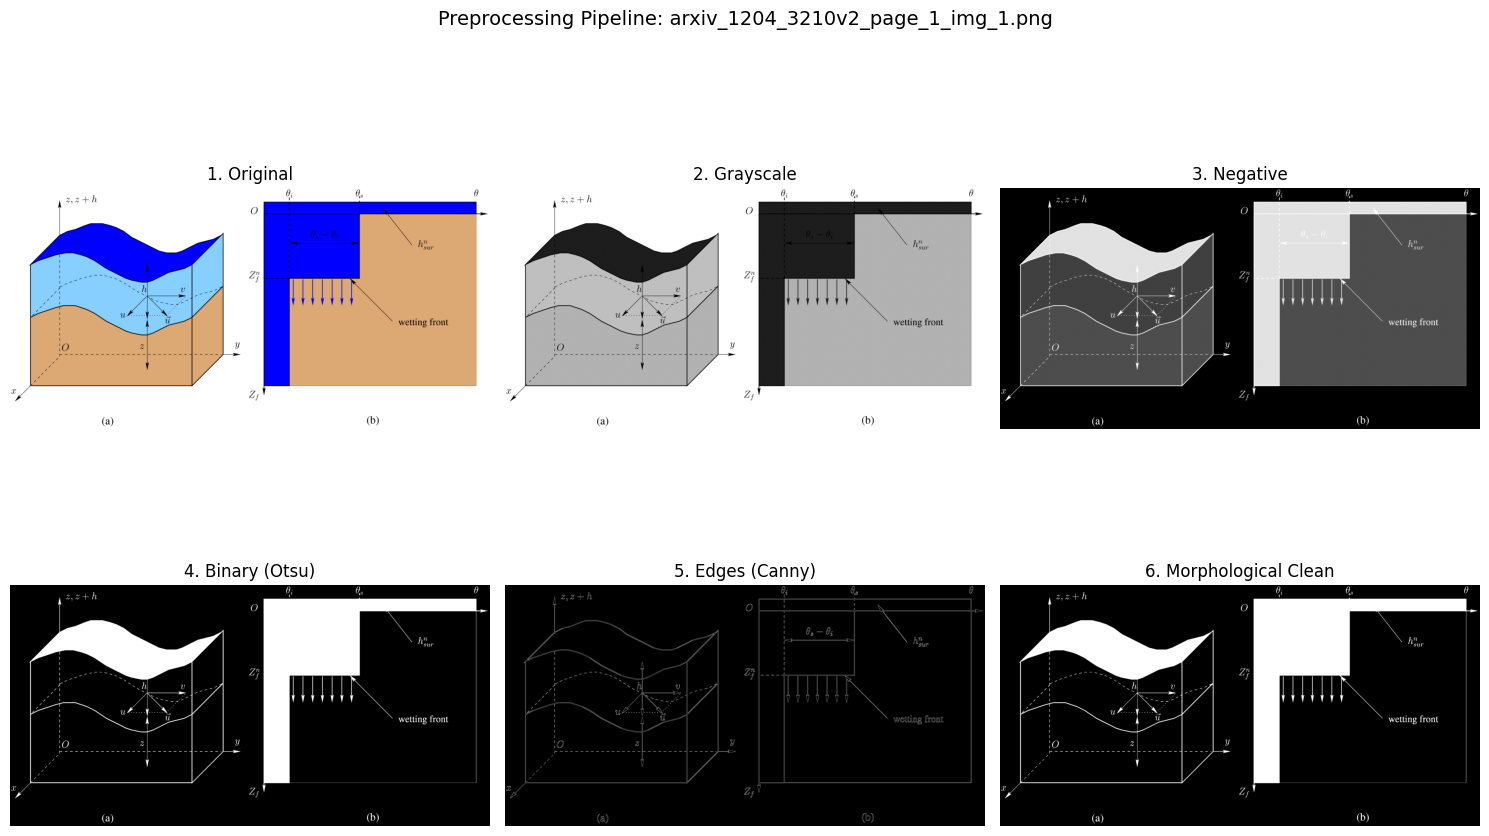


Image: arxiv_1204_3210v2_page_1_img_1.png
Shape: (1463, 2913, 3)


In [6]:
# ============================================================================
# DEMO: Preprocessing Visualization
# ============================================================================
if EXECUTE_EXAMPLES and SHOW_IMAGES:
    import numpy as np
    
    # Use classified_charts instead of images (which may be empty)
    classified_dir = PROJECT_ROOT / "data" / "academic_dataset" / "classified_charts"
    
    # Find first available image from any chart type
    img_path = None
    if classified_dir.exists():
        for chart_type_dir in classified_dir.iterdir():
            if chart_type_dir.is_dir():
                imgs = list(chart_type_dir.glob("*.png"))
                if imgs:
                    img_path = imgs[0]
                    break
    
    if img_path:
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Preprocessing steps
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        negative = 255 - gray
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        edges = cv2.Canny(gray, 50, 150)
        
        # Visualize
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(img_rgb)
        axes[0, 0].set_title("1. Original")
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(gray, cmap='gray')
        axes[0, 1].set_title("2. Grayscale")
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(negative, cmap='gray')
        axes[0, 2].set_title("3. Negative")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(binary, cmap='gray')
        axes[1, 0].set_title("4. Binary (Otsu)")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(edges, cmap='gray')
        axes[1, 1].set_title("5. Edges (Canny)")
        axes[1, 1].axis('off')
        
        # Morphological cleaning
        kernel = np.ones((3, 3), np.uint8)
        cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
        axes[1, 2].imshow(cleaned, cmap='gray')
        axes[1, 2].set_title("6. Morphological Clean")
        axes[1, 2].axis('off')
        
        plt.suptitle(f"Preprocessing Pipeline: {img_path.name}", fontsize=14)
        plt.tight_layout()
        plt.show()
        
        print(f"\nImage: {img_path.name}")
        print(f"Shape: {img.shape}")
    else:
        print("[INFO] No sample images found. Run Data Factory notebooks first.")
elif EXECUTE_EXAMPLES and not SHOW_IMAGES:
    print("[SKIPPED] Set SHOW_IMAGES = True to display preprocessing visualization")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to run preprocessing visualization")

---

## 5. Complete Stage 3 Processing

### Usage Example

```python
from src.core_engine.stages.s3_extraction import Stage3Extraction, ExtractionConfig

# Initialize with full configuration
config = ExtractionConfig(
    use_ml_classifier=True,        # ResNet-18 (94.66% accuracy)
    enable_ocr=True,               # PaddleOCR
    enable_element_detection=True, # K-Means + Contours
    use_color_segmentation=True,   # Better for stacked bars
    enable_vectorization=False,    # Optional: RDP vectorization
)
stage3 = Stage3Extraction(config)

# Process single image directly
result = stage3.process_image(img_bgr, chart_id="chart_001")

# Or process Stage2Output
stage3_output = stage3.process(stage2_output)
```

In [7]:
# ============================================================================
# DEMO: Full Stage 3 Processing
# ============================================================================
if EXECUTE_EXAMPLES:
    from src.core_engine.stages.s3_extraction import Stage3Extraction, ExtractionConfig
    
    # Initialize Stage 3
    config = ExtractionConfig(
        use_ml_classifier=True,
        enable_ocr=True,
        enable_element_detection=True,
        use_color_segmentation=True,
    )
    stage3 = Stage3Extraction(config=config)
    
    print("Stage 3 initialized")
    print(f"  Classifier: {'ResNet-18' if config.use_ml_classifier else 'Simple'}")
    print(f"  OCR: {config.ocr_engine}")
    print(f"  Color Segmentation: {config.use_color_segmentation}")
    
    # Find sample images from classified_charts
    classified_dir = PROJECT_ROOT / "data" / "academic_dataset" / "classified_charts"
    test_images = []
    
    if classified_dir.exists():
        # Prefer bar charts for demo (good for showing element detection)
        bar_dir = classified_dir / "bar"
        if bar_dir.exists():
            bar_imgs = list(bar_dir.glob("*.png"))[:NUM_TEST_IMAGES]
            test_images.extend(bar_imgs)
        
        # Fill remaining with other types
        if len(test_images) < NUM_TEST_IMAGES:
            for chart_type_dir in classified_dir.iterdir():
                if chart_type_dir.is_dir() and chart_type_dir.name != "bar":
                    for img_path in chart_type_dir.glob("*.png"):
                        if img_path not in test_images:
                            test_images.append(img_path)
                            if len(test_images) >= NUM_TEST_IMAGES:
                                break
                if len(test_images) >= NUM_TEST_IMAGES:
                    break
    
    if test_images:
        print(f"\n{'='*60}")
        print(f"Processing {len(test_images)} test images...")
        print(f"{'='*60}")
        
        for i, img_path in enumerate(test_images, 1):
            img = cv2.imread(str(img_path))
            result = stage3.process_image(img, chart_id=img_path.stem)
            
            print(f"\n[{i}/{len(test_images)}] {img_path.name}")
            print(f"  Chart Type: {result.chart_type.value}")
            
            # Access confidence from ExtractionConfidence object
            if result.confidence:
                print(f"  Confidence: {result.confidence.overall:.2%} (class: {result.confidence.classification:.2%}, ocr: {result.confidence.ocr:.2%})")
            
            print(f"  OCR Texts: {len(result.texts)}, Elements: {len(result.elements)}")
            
            if result.axis_info and result.axis_info.x_range:
                print(f"  Axis X: {result.axis_info.x_range}, Y: {result.axis_info.y_range}")
            
            # Show sample texts
            if result.texts:
                sample_texts = [t.text for t in result.texts[:3]]
                print(f"  Sample texts: {sample_texts}")
            
            if result.warnings:
                print(f"  Warnings: {result.warnings[:2]}")
        
        print(f"\n{'='*60}")
        print(f"Processed {len(test_images)} images successfully")
        print(f"{'='*60}")
    else:
        print("[INFO] No sample images found. Run Data Factory notebooks first.")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to run full pipeline")
    print("\nExpected output:")
    print("  Chart Type: bar")
    print("  Overall Confidence: 92.50%")
    print("  OCR Texts: 12")
    print("  Elements: 5")

Stage 3 initialized
  Classifier: ResNet-18
  OCR: easyocr
  Color Segmentation: True

Processing 20 test images...


Using CPU. Note: This module is much faster with a GPU.



[1/20] arxiv_0710_2523v2_page_14_img_1.png
  Chart Type: line
  OCR Texts: 9, Elements: 7
  Sample texts: ['Theme A: Development', 'Theme B: Neural Excitability, Synapses, and Glia: Cellular Mechanisms', 'Theme C: Sensory and Motor Systems']


d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\e


[2/20] arxiv_0710_2523v2_page_9_img_1.png
  Chart Type: bar
  OCR Texts: 5, Elements: 10
  Sample texts: ['X', '104', '[']

[3/20] arxiv_0808_3562v1_page_14_img_2.png
  Chart Type: bar
  OCR Texts: 5, Elements: 41
  Sample texts: ['2e+05', '4e+05', '6e+05']

[4/20] arxiv_0808_3562v1_page_14_img_3.png
  Chart Type: bar
  OCR Texts: 5, Elements: 83
  Sample texts: ['2e+05', '4e+05', '6e+05']

[5/20] arxiv_0809_3351v1_page_5_img_1.png
  Chart Type: bar
  OCR Texts: 16, Elements: 12
  Sample texts: ['Image start', 'Frame', 'Transfer']

[6/20] arxiv_0810_3252v1_page_4_img_1.png
  Chart Type: bar
  OCR Texts: 12, Elements: 88
  Sample texts: ['IGR J17544-2619', 'Data from IBISISGRI', '5']

[7/20] arxiv_0810_3875v1_page_2_img_1.png
  Chart Type: unknown
  OCR Texts: 50, Elements: 63
  Sample texts: ['OMC', 'Search form', 'Mozilla Firefox']

[8/20] arxiv_0811_1074v1_page_6_img_1.png
  Chart Type: bar
  OCR Texts: 6, Elements: 11
  Sample texts: ['line formation height', 'at limb', 'line forat

---

## 6. Visualization: Detection Results

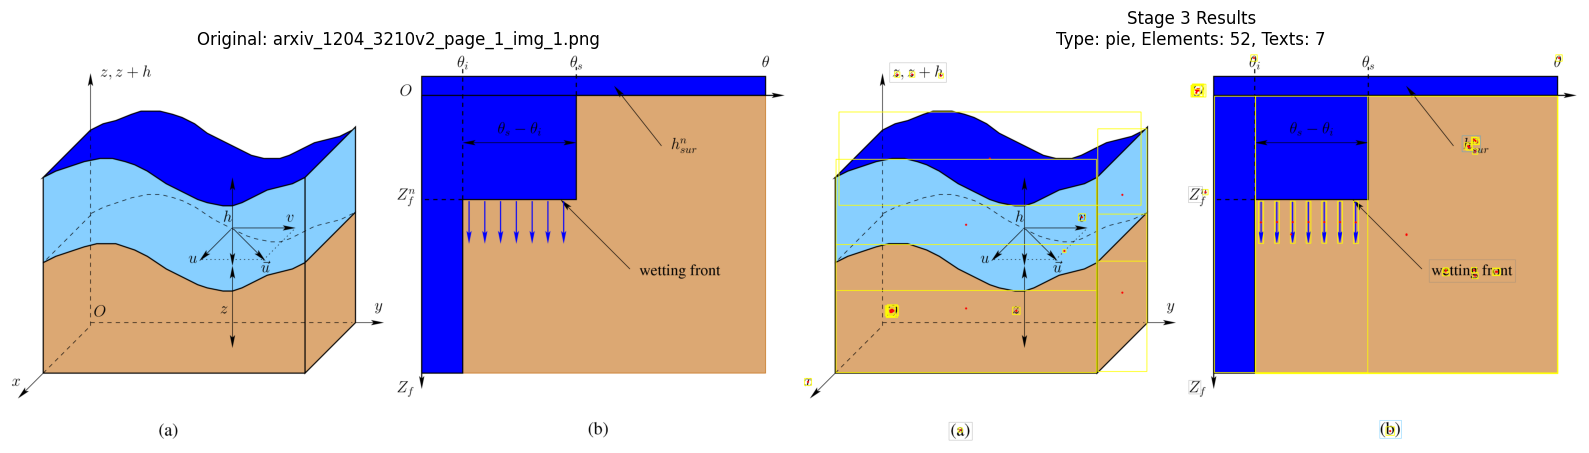

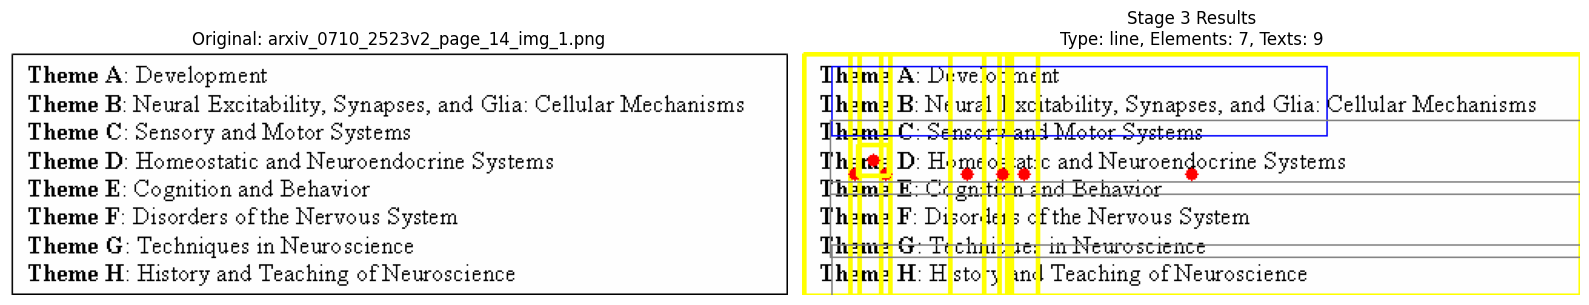

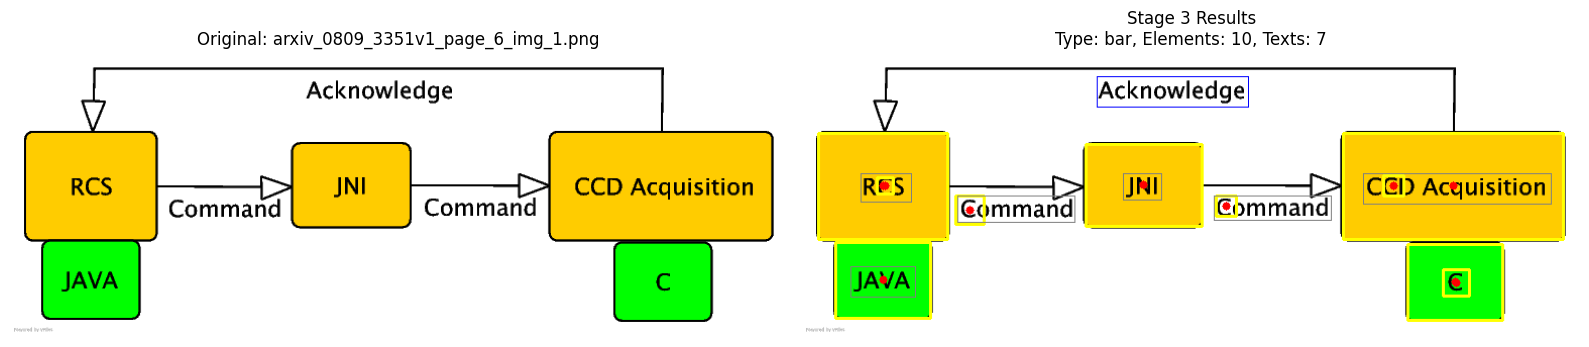

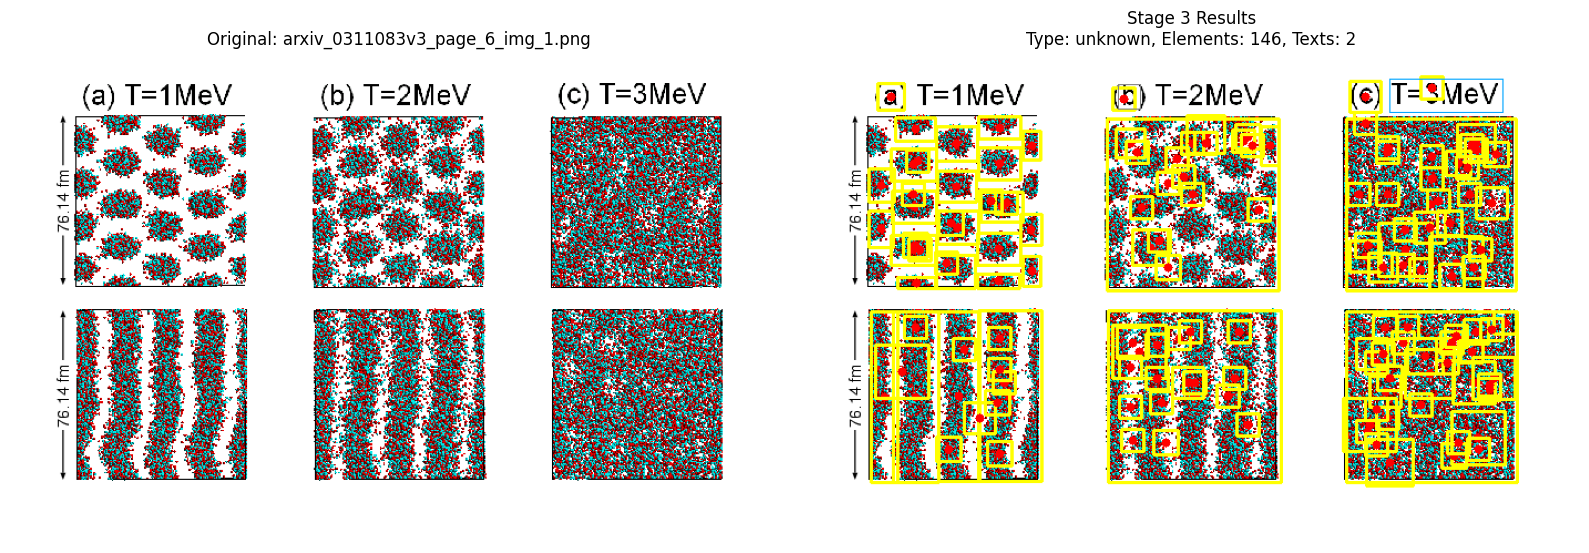

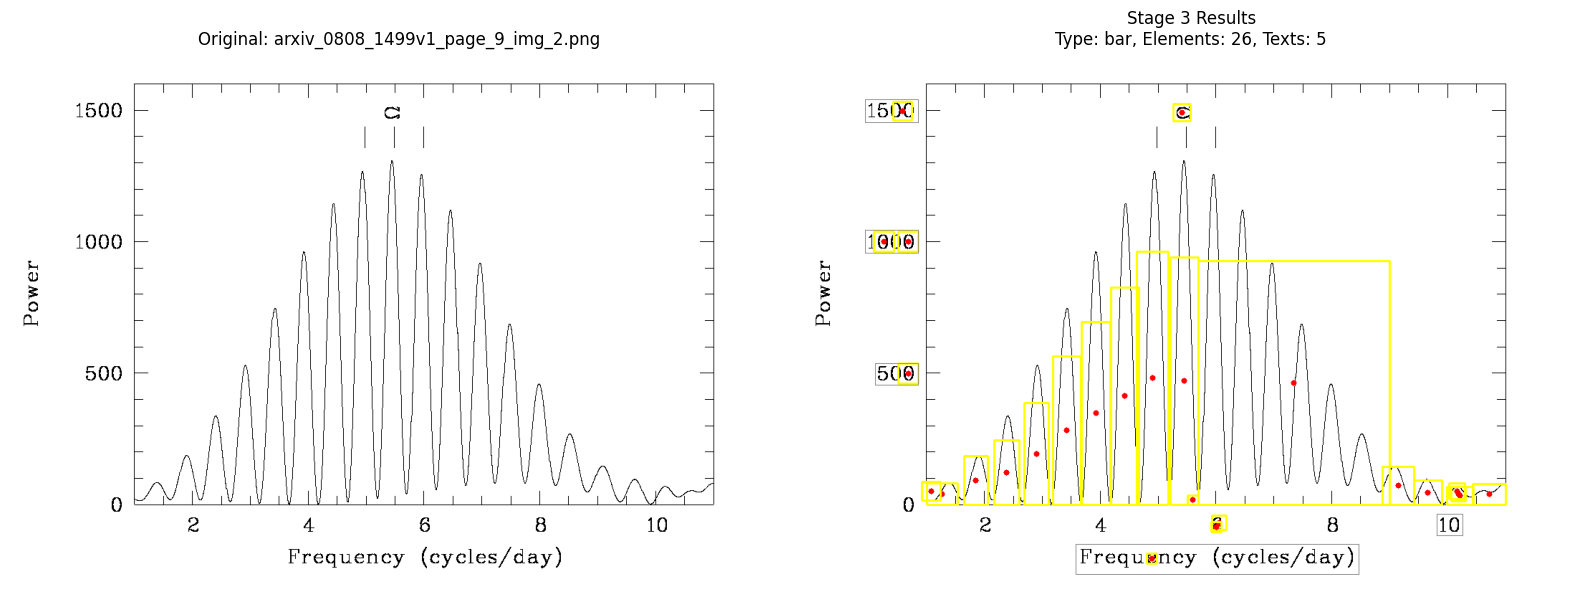

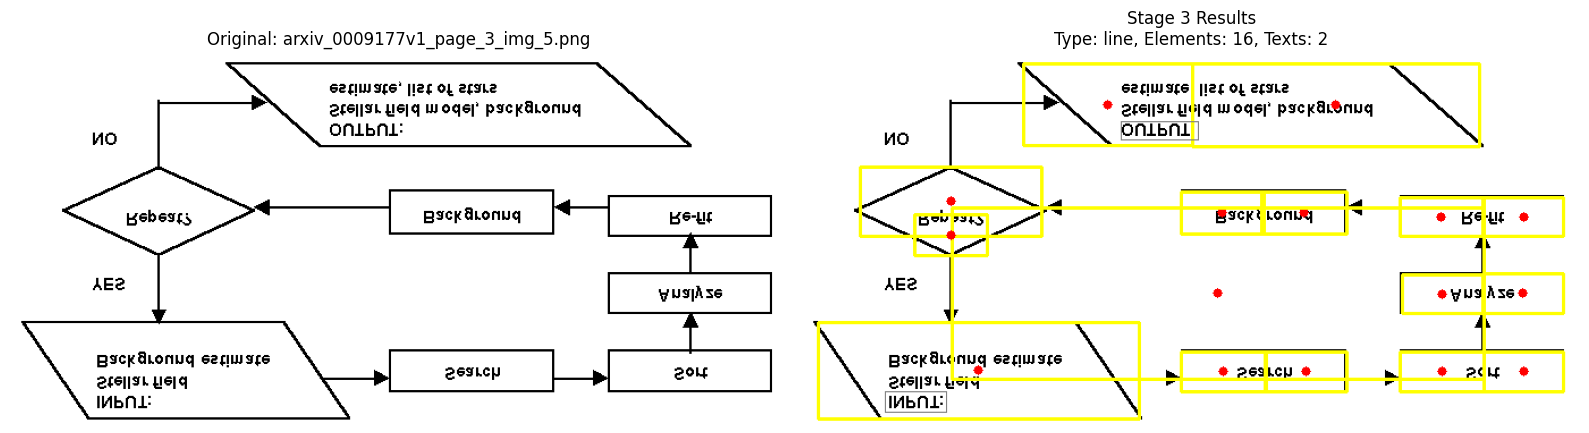

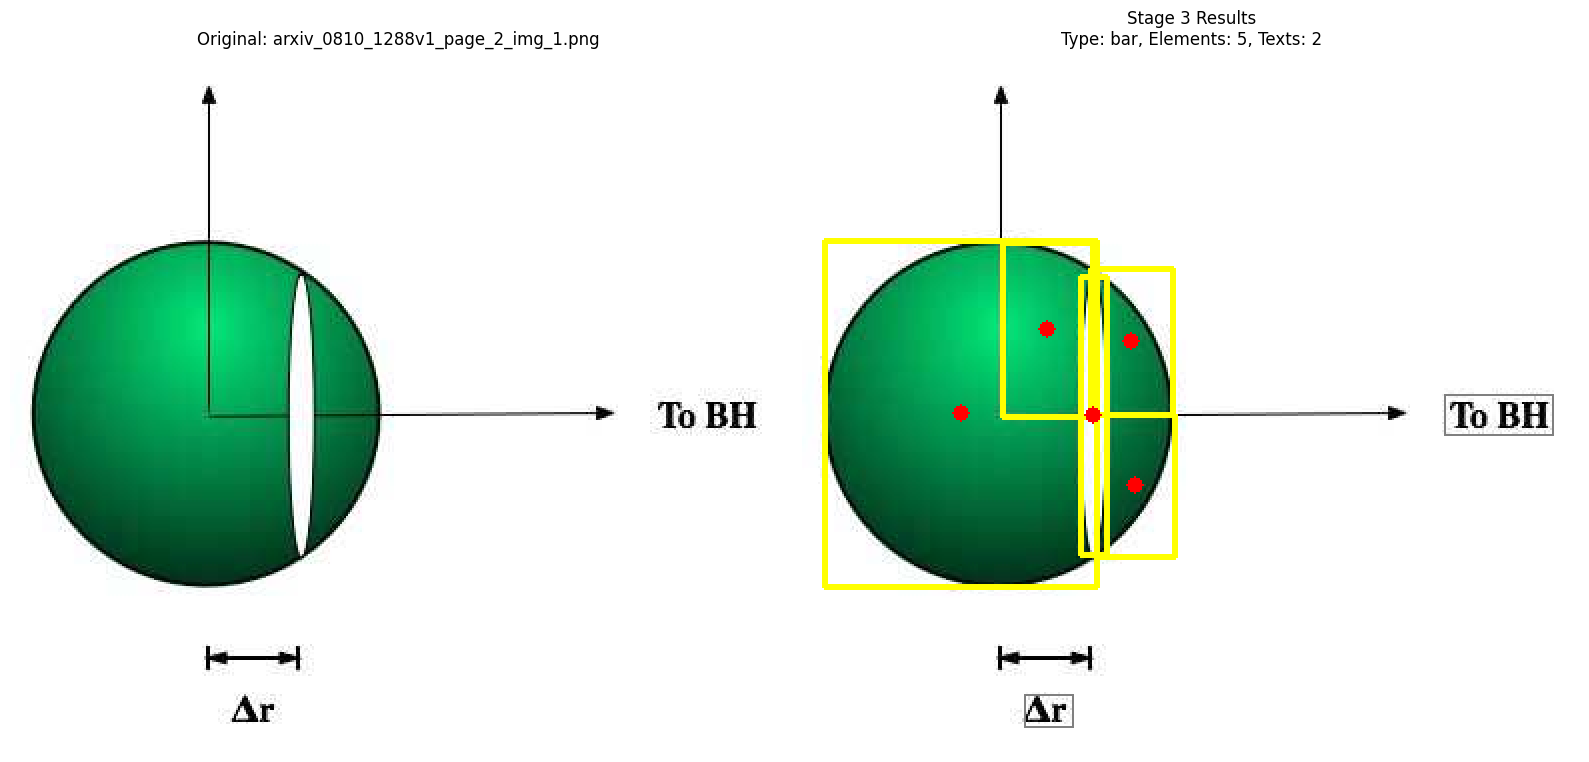

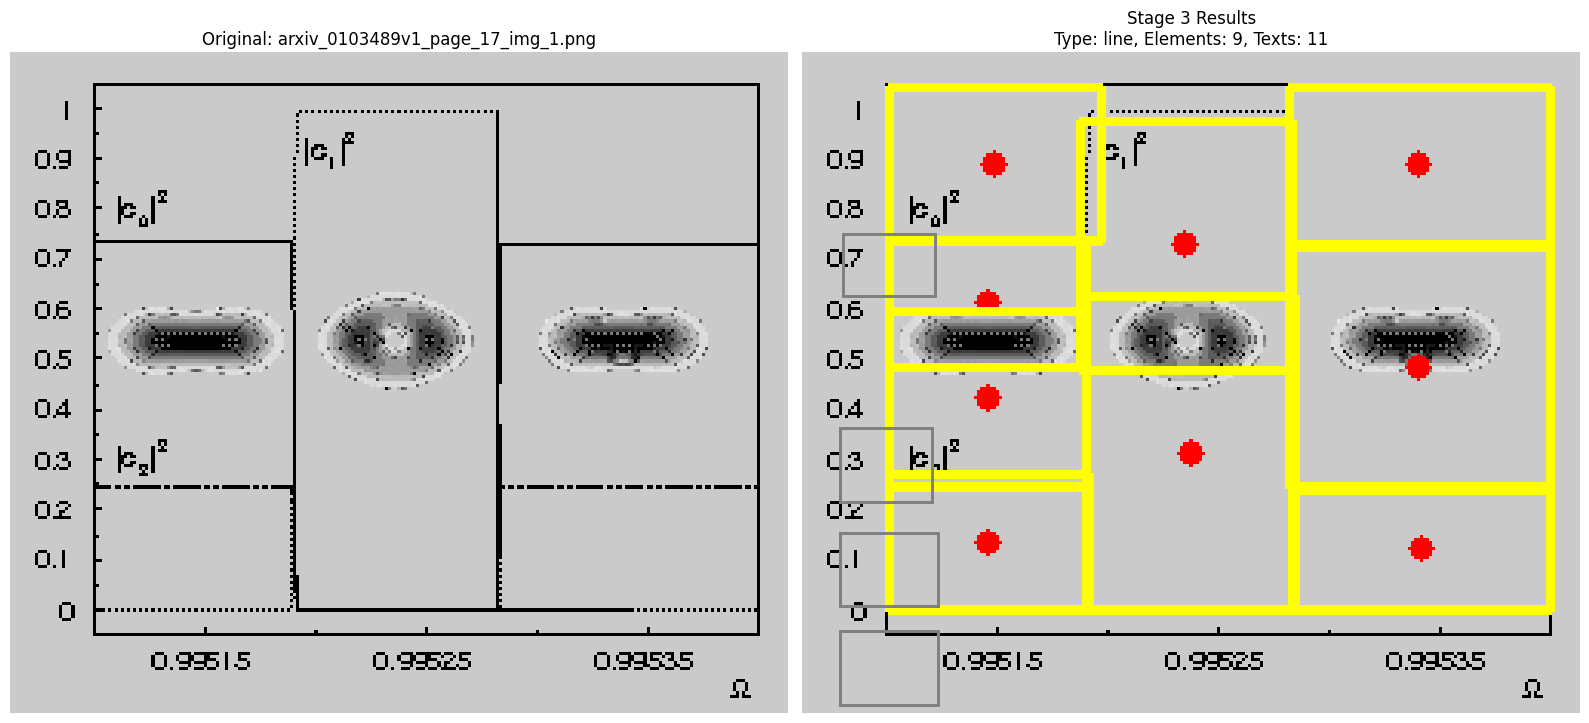

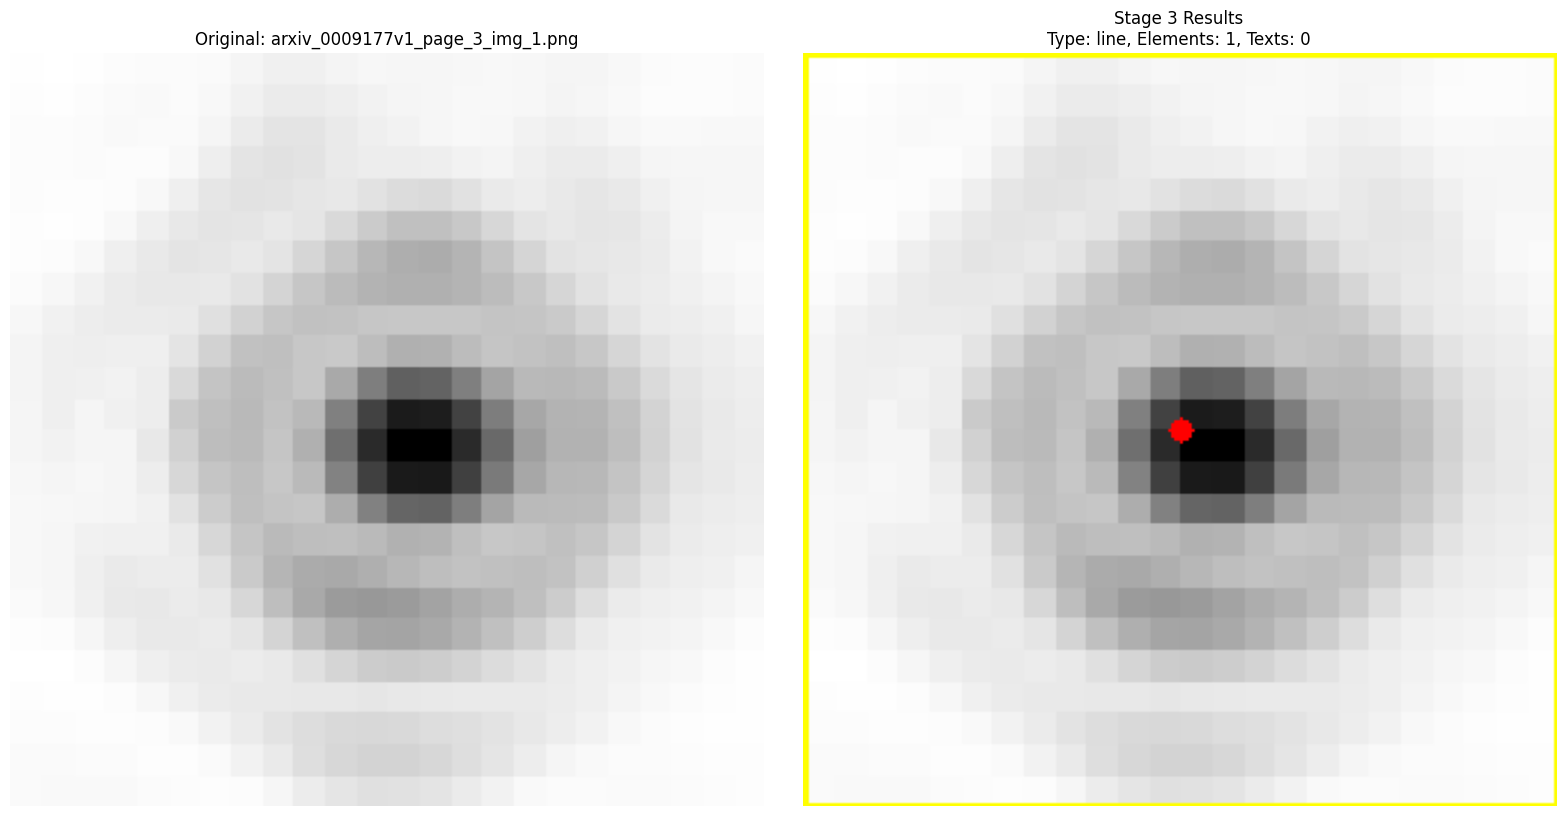


Color Legend:
  Cyan boxes = Elements (bars/points)
  Red = Title, Green = X-labels, Blue = Y-labels
  Orange = Legend, Purple = Values


In [8]:
# ============================================================================
# DEMO: Visualize Stage 3 Results
# ============================================================================
if EXECUTE_EXAMPLES and SHOW_IMAGES:
    # Find and process images for visualization
    classified_dir = PROJECT_ROOT / "data" / "academic_dataset" / "classified_charts"
    from src.core_engine.stages.s3_extraction import Stage3Extraction, ExtractionConfig
    
    # Initialize if not already done
    if 'stage3' not in dir():
        config = ExtractionConfig(use_ml_classifier=True, enable_ocr=True, enable_element_detection=True)
        stage3 = Stage3Extraction(config=config)
    
    # Get test images
    test_images = []
    if classified_dir.exists():
        for chart_type_dir in classified_dir.iterdir():
            if chart_type_dir.is_dir():
                imgs = list(chart_type_dir.glob("*.png"))[:1]  # 1 per type
                test_images.extend(imgs)
            if len(test_images) >= NUM_TEST_IMAGES:
                break
    
    # Role colors for text boxes
    role_colors = {
        'title': (255, 0, 0),
        'xlabel': (0, 255, 0),
        'ylabel': (0, 0, 255),
        'legend': (255, 165, 0),
        'value': (128, 0, 128),
    }
    
    for img_path in test_images[:NUM_TEST_IMAGES]:
        img = cv2.imread(str(img_path))
        result = stage3.process_image(img, chart_id=img_path.stem)
        
        # Create visualization
        img_viz = img.copy()
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Draw elements
        for elem in result.elements:
            x1, y1 = int(elem.bbox.x_min), int(elem.bbox.y_min)
            x2, y2 = int(elem.bbox.x_max), int(elem.bbox.y_max)
            cv2.rectangle(img_viz, (x1, y1), (x2, y2), (0, 255, 255), 2)
            cv2.circle(img_viz, (int(elem.center.x), int(elem.center.y)), 4, (0, 0, 255), -1)
        
        # Draw text boxes
        for text in result.texts[:10]:  # Limit for clarity
            color = role_colors.get(text.role, (128, 128, 128))
            x1, y1 = int(text.bbox.x_min), int(text.bbox.y_min)
            x2, y2 = int(text.bbox.x_max), int(text.bbox.y_max)
            cv2.rectangle(img_viz, (x1, y1), (x2, y2), color, 1)
        
        # Display
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        axes[0].imshow(img_rgb)
        axes[0].set_title(f"Original: {img_path.name}")
        axes[0].axis('off')
        
        axes[1].imshow(cv2.cvtColor(img_viz, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Stage 3 Results\nType: {result.chart_type.value}, Elements: {len(result.elements)}, Texts: {len(result.texts)}")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    # Legend
    print("\nColor Legend:")
    print("  Cyan boxes = Elements (bars/points)")
    print("  Red = Title, Green = X-labels, Blue = Y-labels")
    print("  Orange = Legend, Purple = Values")

elif EXECUTE_EXAMPLES and not SHOW_IMAGES:
    print("[SKIPPED] Set SHOW_IMAGES = True to display visualization")
    print("  (already processed images in previous cell)")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to visualize results")

---

## Summary

### Stage 3 Components

| Component | Technology | Accuracy/Speed |
| --- | --- | --- |
| Classifier | ResNet-18 (ONNX) | 94.66%, 6.9ms |
| OCR | PaddleOCR | High accuracy, multi-lang |
| Element Detector | K-Means + Contours | Improved for stacked bars |
| Preprocessor | OpenCV | Negative + CLAHE |

### Configuration Options

| Parameter | Default | Description |
| --- | --- | --- |
| `use_ml_classifier` | True | Use ResNet-18 (vs SimpleClassifier) |
| `enable_ocr` | True | Run OCR text extraction |
| `ocr_engine` | paddleocr | OCR backend |
| `enable_element_detection` | True | Detect chart elements |
| `use_color_segmentation` | True | K-Means for colors |
| `enable_vectorization` | False | RDP line vectorization |

### Error Handling

| Error | Severity | Action |
| --- | --- | --- |
| Classifier model missing | WARNING | Use SimpleClassifier |
| OCR failure | WARNING | Return empty texts |
| No elements detected | NORMAL | Return empty list |
| Classification uncertain | WARNING | Default to "unknown" |

---

**Previous**: [Stage 2 - Detection](02_stage2_detection.ipynb)  
**Next**: [Stage 4 - Reasoning](04_stage4_reasoning.ipynb)